In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [312]:
df = pd.read_csv("car_price.csv")

In [313]:
df.head()

,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,engine,manufacture,Seats
0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,1956 cc,2017.0,5 Seats
1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,1330 cc,2021.0,5 Seats
2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2494 cc,2016.0,5 Seats
3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,1199 cc,2018.0,5 Seats
4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,1199 cc,2016.0,5 Seats


In [314]:
# Check Missing value
# Check Mixed Data: Car_name, Car_prices , Kms_driven
# Check date formation

# Data Cleaning
### Handle Missing Data: Delete, Fill
### Standardizing data formats
### Filter unwanted outliers if needed
### Handling Duplicates

In [316]:
# Check Datatypes 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5512 entries, 0 to 5511
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             5512 non-null   object 
 1   car_prices_in_rupee  5504 non-null   object 
 2   kms_driven           5507 non-null   object 
 3   fuel_type            5509 non-null   object 
 4   transmission         5508 non-null   object 
 5   ownership            5499 non-null   object 
 6   engine               5504 non-null   object 
 7   manufacture          5511 non-null   float64
 8   Seats                5501 non-null   object 
dtypes: float64(1), object(8)
memory usage: 387.7+ KB


In [317]:
df.shape

(5512, 9)

# Handle Missing Data: Delete, Fill

In [319]:
df.isnull().sum()/5512*100

car_name               0.000000
car_prices_in_rupee    0.145138
kms_driven             0.090711
fuel_type              0.054427
transmission           0.072569
ownership              0.235849
engine                 0.145138
manufacture            0.018142
Seats                  0.199565
dtype: float64

In [320]:
# We can remove the missing data in this case since we donot have more than 1% missing data.

In [321]:
### Incase we want to fill . We can fill with mean/mode value.

# num_cols= [car_name','car_prices_in_rupee','kms_driven','fuel_type','transmission','ownership','engine','manufacture','Seats']
# df[num_cols]= df[num_cols].fillna([num_cols].mean())

In [322]:
df.dropna(inplace=True)

In [323]:
df.isnull().sum()

car_name               0
car_prices_in_rupee    0
kms_driven             0
fuel_type              0
transmission           0
ownership              0
engine                 0
manufacture            0
Seats                  0
dtype: int64

# Now we will work on each column

## 1. car_name

In [326]:

df['car_name'].unique()

array(['Jeep Compass 2.0 Longitude Option BSIV',
       'Renault Duster RXZ Turbo CVT', 'Toyota Camry 2.5 G', ...,
       'Mercedes-Benz A-Class Limousine A 200',
       'Volvo XC 90 D5 Momentum BSIV', 'BMW M Series M4 Coupe'],
      dtype=object)

## We Observe that Brand/Company name and Car name is together. So we have to separate.

In [328]:
df['car_name'][0]

'Jeep Compass 2.0 Longitude Option BSIV'

In [329]:
# We can use slicing to get the portion of the string

In [330]:
df['car_name'][0].index(" ")

4

In [331]:
df['car_name'][0][0:4]

'Jeep'

In [332]:
# OR

df['car_name'][0][:df['car_name'][0].index(" ")]


'Jeep'

In [333]:
# Create user Def function

# to do this we have to save the above in a varibale

x= df['car_name'][0]
x.index(" ")

4

In [334]:
x[0:x.index(" ")]

'Jeep'

In [335]:
def company_name(x):
    return x[0:x.index(" ")]

In [336]:
df['company_name']=df["car_name"].apply(company_name)

In [337]:
df.head()  # we have successfully separated Company Name and added a column to the dataset.

,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,engine,manufacture,Seats,company_name
0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,1956 cc,2017.0,5 Seats,Jeep
1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,1330 cc,2021.0,5 Seats,Renault
2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2494 cc,2016.0,5 Seats,Toyota
3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,1199 cc,2018.0,5 Seats,Honda
4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,1199 cc,2016.0,5 Seats,Volkswagen


## Now we separate the Car name following the similar process.

In [339]:
x

'Jeep Compass 2.0 Longitude Option BSIV'

In [340]:
x.index(" ")

4

In [341]:
x[x.index(" "):]   # we get a space ' Compass 2.0 Longitude Option BSIV' . So we need to remove that space.

' Compass 2.0 Longitude Option BSIV'

In [342]:
x[x.index(" ")+1:] 

'Compass 2.0 Longitude Option BSIV'

In [343]:
def car_name(x):
    return x[x.index(" ")+1:] 

In [344]:
df['car_name'].apply(car_name)

0       Compass 2.0 Longitude Option BSIV
1                    Duster RXZ Turbo CVT
2                             Camry 2.5 G
3                             Jazz VX CVT
4                   Polo 1.2 MPI Highline
                      ...                
5506                        X5 xDrive 30d
5507                  X1 sDrive 20d xLine
5508                    M Series M4 Coupe
5509                  XF 2.2 Litre Luxury
5510                       7 Series 730Ld
Name: car_name, Length: 5460, dtype: object

In [345]:
# we replace the old car_name column to the new car_name that we just created

In [346]:
df['car_name']=df['car_name'].apply(car_name)

In [347]:
df.head()

,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,engine,manufacture,Seats,company_name
0,Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,1956 cc,2017.0,5 Seats,Jeep
1,Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,1330 cc,2021.0,5 Seats,Renault
2,Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2494 cc,2016.0,5 Seats,Toyota
3,Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,1199 cc,2018.0,5 Seats,Honda
4,Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,1199 cc,2016.0,5 Seats,Volkswagen


## 2. car_prices_in_rupee

In [349]:
df["car_prices_in_rupee"]

0       10.03 Lakh
1       12.83 Lakh
2       16.40 Lakh
3        7.77 Lakh
4        5.15 Lakh
           ...    
5506    32.90 Lakh
5507    28.90 Lakh
5508    64.90 Lakh
5509    13.75 Lakh
5510    29.90 Lakh
Name: car_prices_in_rupee, Length: 5460, dtype: object

In [350]:
# Some data are like 35,000   ,   29.80 lakh   , 1.02 Crore    

# First we will remove the comma(,) from figures like 35,000

# next we have to make one format. We will convert lakh and Crore to Thousand.

In [351]:
df["car_prices_in_rupee"]=df["car_prices_in_rupee"].str.replace(",","")

In [352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5460 entries, 0 to 5510
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             5460 non-null   object 
 1   car_prices_in_rupee  5460 non-null   object 
 2   kms_driven           5460 non-null   object 
 3   fuel_type            5460 non-null   object 
 4   transmission         5460 non-null   object 
 5   ownership            5460 non-null   object 
 6   engine               5460 non-null   object 
 7   manufacture          5460 non-null   float64
 8   Seats                5460 non-null   object 
 9   company_name         5460 non-null   object 
dtypes: float64(1), object(9)
memory usage: 598.3+ KB


In [353]:
# we will convert all to thousand (lakh to thousand will be 100,000 and Crore to thousand will be 10,000,000)

In [354]:
def rupee_change(x):
    p = x.split(" ")   # we will get for example["1.02","Crore"] , we will get in string format
    try:
        if p[1] == "Lakh" :
            return str(round(float(p[0])*100000,1))
        elif p[1] == "Crore" :
            return str(round(float(p[0])*10000000,1))

    except:
        return (x) 
        

In [355]:
df["car_prices_in_rupee"]= df["car_prices_in_rupee"].apply(rupee_change)

In [356]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5460 entries, 0 to 5510
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             5460 non-null   object 
 1   car_prices_in_rupee  5460 non-null   object 
 2   kms_driven           5460 non-null   object 
 3   fuel_type            5460 non-null   object 
 4   transmission         5460 non-null   object 
 5   ownership            5460 non-null   object 
 6   engine               5460 non-null   object 
 7   manufacture          5460 non-null   float64
 8   Seats                5460 non-null   object 
 9   company_name         5460 non-null   object 
dtypes: float64(1), object(9)
memory usage: 598.3+ KB


In [357]:
# Converting the datatype to float

In [358]:
df["car_prices_in_rupee"]=df["car_prices_in_rupee"].astype("float")   

In [359]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5460 entries, 0 to 5510
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             5460 non-null   object 
 1   car_prices_in_rupee  5460 non-null   float64
 2   kms_driven           5460 non-null   object 
 3   fuel_type            5460 non-null   object 
 4   transmission         5460 non-null   object 
 5   ownership            5460 non-null   object 
 6   engine               5460 non-null   object 
 7   manufacture          5460 non-null   float64
 8   Seats                5460 non-null   object 
 9   company_name         5460 non-null   object 
dtypes: float64(2), object(8)
memory usage: 598.3+ KB


## 3. kms_driven

In [361]:
# we will remove the 'kms' , (,)comma and simplify numbers

In [362]:
df["kms_driven"]

0       86,226 kms
1       13,248 kms
2       60,343 kms
3       26,696 kms
4       69,414 kms
           ...    
5506    99,000 kms
5507    45,000 kms
5508    29,000 kms
5509    90,000 kms
5510    79,000 kms
Name: kms_driven, Length: 5460, dtype: object

In [363]:
df["kms_driven"]=df["kms_driven"].str.replace(",", "")

In [364]:
df["kms_driven"]

0       86226 kms
1       13248 kms
2       60343 kms
3       26696 kms
4       69414 kms
          ...    
5506    99000 kms
5507    45000 kms
5508    29000 kms
5509    90000 kms
5510    79000 kms
Name: kms_driven, Length: 5460, dtype: object

In [365]:
df["kms_driven"]=df["kms_driven"].str.replace(" kms","")

In [366]:
df["kms_driven"]

0       86226
1       13248
2       60343
3       26696
4       69414
        ...  
5506    99000
5507    45000
5508    29000
5509    90000
5510    79000
Name: kms_driven, Length: 5460, dtype: object

In [367]:
df["kms_driven"]=df["kms_driven"].astype("int")

In [368]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5460 entries, 0 to 5510
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             5460 non-null   object 
 1   car_prices_in_rupee  5460 non-null   float64
 2   kms_driven           5460 non-null   int32  
 3   fuel_type            5460 non-null   object 
 4   transmission         5460 non-null   object 
 5   ownership            5460 non-null   object 
 6   engine               5460 non-null   object 
 7   manufacture          5460 non-null   float64
 8   Seats                5460 non-null   object 
 9   company_name         5460 non-null   object 
dtypes: float64(2), int32(1), object(7)
memory usage: 576.9+ KB


## 4. engine

In [370]:
df["engine"]

0       1956 cc
1       1330 cc
2       2494 cc
3       1199 cc
4       1199 cc
         ...   
5506    1999 cc
5507    2995 cc
5508    1968 cc
5509    2755 cc
5510    2967 cc
Name: engine, Length: 5460, dtype: object

In [371]:
df["engine"]=df["engine"].str.replace(" cc","")

In [372]:
df["engine"]

0       1956
1       1330
2       2494
3       1199
4       1199
        ... 
5506    1999
5507    2995
5508    1968
5509    2755
5510    2967
Name: engine, Length: 5460, dtype: object

In [373]:
df["engine"]=df["engine"].astype("int")

In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5460 entries, 0 to 5510
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             5460 non-null   object 
 1   car_prices_in_rupee  5460 non-null   float64
 2   kms_driven           5460 non-null   int32  
 3   fuel_type            5460 non-null   object 
 4   transmission         5460 non-null   object 
 5   ownership            5460 non-null   object 
 6   engine               5460 non-null   int32  
 7   manufacture          5460 non-null   float64
 8   Seats                5460 non-null   object 
 9   company_name         5460 non-null   object 
dtypes: float64(2), int32(2), object(6)
memory usage: 555.6+ KB


## 5. Seats

In [376]:
df["Seats"]

0       5 Seats
1       5 Seats
2       5 Seats
3       5 Seats
4       5 Seats
         ...   
5506    5 Seats
5507    7 Seats
5508    5 Seats
5509    5 Seats
5510    6 Seats
Name: Seats, Length: 5460, dtype: object

In [377]:
df["Seats"]=df["Seats"].str.replace(" Seats","")

In [378]:
df["Seats"]=df["Seats"].astype("int")

In [379]:
df['manufacture']= df['manufacture'].astype("int")

In [380]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5460 entries, 0 to 5510
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             5460 non-null   object 
 1   car_prices_in_rupee  5460 non-null   float64
 2   kms_driven           5460 non-null   int32  
 3   fuel_type            5460 non-null   object 
 4   transmission         5460 non-null   object 
 5   ownership            5460 non-null   object 
 6   engine               5460 non-null   int32  
 7   manufacture          5460 non-null   int32  
 8   Seats                5460 non-null   int32  
 9   company_name         5460 non-null   object 
dtypes: float64(1), int32(4), object(5)
memory usage: 512.9+ KB


In [381]:
df.head(3)

,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,engine,manufacture,Seats,company_name
0,Compass 2.0 Longitude Option BSIV,1003000.0,86226,Diesel,Manual,1st Owner,1956,2017,5,Jeep
1,Duster RXZ Turbo CVT,1283000.0,13248,Petrol,Automatic,1st Owner,1330,2021,5,Renault
2,Camry 2.5 G,1640000.0,60343,Petrol,Automatic,1st Owner,2494,2016,5,Toyota


## Data Cleaning For ML

In [383]:
# LabelEncoder to encode the categorical columns
# Outlier Detection & Handling
# Data Scaling & transformation

In [384]:
df.head(3)

,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,engine,manufacture,Seats,company_name
0,Compass 2.0 Longitude Option BSIV,1003000.0,86226,Diesel,Manual,1st Owner,1956,2017,5,Jeep
1,Duster RXZ Turbo CVT,1283000.0,13248,Petrol,Automatic,1st Owner,1330,2021,5,Renault
2,Camry 2.5 G,1640000.0,60343,Petrol,Automatic,1st Owner,2494,2016,5,Toyota


## car_name

In [386]:
df['car_name'].nunique()

1884

In [387]:
df['car_name'].value_counts()

car_name
Alto 800 LXI                        53
Swift VXI                           45
Swift Dzire VDI                     42
Swift Dzire VXI                     42
Wagon R VXI BS IV                   41
                                    ..
Swift Dzire ZXI 1.2 BS IV            1
Tigor XZ Plus                        1
S-Class 320 CDI                      1
Manza Aura (ABS) Quadrajet BS IV     1
M Series M4 Coupe                    1
Name: count, Length: 1884, dtype: int64

In [388]:
from sklearn.preprocessing import LabelEncoder , StandardScaler

In [389]:
df['car_name'] = LabelEncoder().fit_transform(df['car_name'])

In [390]:
df.head(3)

,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,engine,manufacture,Seats,company_name
0,425,1003000.0,86226,Diesel,Manual,1st Owner,1956,2017,5,Jeep
1,506,1283000.0,13248,Petrol,Automatic,1st Owner,1330,2021,5,Renault
2,289,1640000.0,60343,Petrol,Automatic,1st Owner,2494,2016,5,Toyota


In [391]:
df.rename(columns={'car_name':'car_name_encoded'}, inplace = True)

In [503]:
df.head(3)

,car_name_encoded,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,engine,manufacture,Seats,company_name,fuel_type_encoded,transmission_encoded,ownership_encoded,manufacture_year,company_name_encoded
0,425,1003000.0,86226,Diesel,Manual,1st Owner,1956,2017-01-01,5,Jeep,1,1,1,2017,12
1,506,1283000.0,13248,Petrol,Automatic,1st Owner,1330,2021-01-01,5,Renault,4,0,1,2021,26
2,289,1640000.0,60343,Petrol,Automatic,1st Owner,2494,2016-01-01,5,Toyota,4,0,1,2016,29


## fuel_type

In [394]:
df['fuel_type_encoded']= LabelEncoder().fit_transform(df['fuel_type'])

## transmission

In [396]:
df['transmission_encoded'] = LabelEncoder().fit_transform(df['transmission'])

## ownership

In [398]:
df['ownership_encoded'] = LabelEncoder().fit_transform(df['ownership'])

## manufacture

In [400]:
df['manufacture'] = pd.to_datetime(df['manufacture'], format='%Y')

In [401]:
df['manufacture_year']= df['manufacture'].dt.year

In [402]:
# if needd , df.drop(columns=['manufacture'], inplace =True)   

In [403]:
#OR

In [404]:
#df.drop('manufacture', axis =1 , inplace= True)

## company_name

In [406]:
df['company_name_encoded'] = LabelEncoder().fit_transform(df['company_name'])

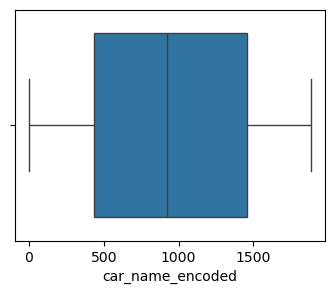

In [407]:
plt.figure(figsize=(4,3))
sns.boxplot(x = 'car_name_encoded' , data = df)
plt.show()

[]

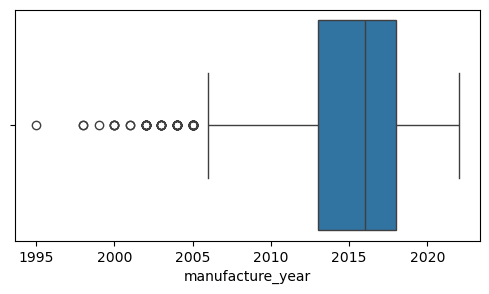

In [408]:
plt.figure(figsize=(6,3))
sns.boxplot(x = 'manufacture_year',data=df)
plt.plot()